# Customer Segmentation — Data Cleaning & RFM Feature Engineering

In this notebook we transform 541 k raw transaction rows into a single RFM table — one row per customer. The three RFM features (Recency, Frequency, Monetary) capture the most predictive dimensions of customer behaviour for segmentation.

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

sys.path.insert(0, os.getcwd())
from utils import load_data, clean_transactions, build_rfm

In [2]:
df_raw = load_data()
print('Raw shape:', df_raw.shape)
df_raw.head()

Raw shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Clean Transactions

We apply four rules in sequence, documenting how many rows each removes:

1. **Drop missing CustomerID** — rows without a customer ID cannot be attributed to a customer and are useless for RFM aggregation.
2. **Remove cancellations** — invoices whose number starts with `'C'` represent returns/refunds, not purchases.
3. **Remove non-positive Quantity / UnitPrice** — zero or negative values indicate data errors or free samples that distort monetary aggregations.
4. **Parse InvoiceDate** — converts the date string to a proper datetime for recency calculations.

In [3]:
df_clean, stats = clean_transactions(df_raw)
print('Rows removed — missing CustomerID :', stats['missing_customer_id'])
print('Rows removed — cancellations       :', stats['cancellations'])
print('Rows removed — non-positive Q/P    :', stats['non_positive'])
print('Rows kept                          :', stats['rows_kept'])
print(f'Retention rate: {stats["rows_kept"] / len(df_raw):.1%}')

Rows removed — missing CustomerID : 135080
Rows removed — cancellations       : 8905
Rows removed — non-positive Q/P    : 40
Rows kept                          : 397884
Retention rate: 73.4%


In [4]:
print('InvoiceDate dtype after parsing:', df_clean['InvoiceDate'].dtype)
print('Date range:', df_clean['InvoiceDate'].min(), '-->', df_clean['InvoiceDate'].max())
df_clean.head()

InvoiceDate dtype after parsing: datetime64[ns]
Date range: 2010-12-01 08:26:00 --> 2011-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Compute TotalPrice

`TotalPrice = Quantity × UnitPrice` gives the line-item revenue. This is the building block for the Monetary dimension of RFM.

In [5]:
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
print('TotalPrice added. Sample stats:')
df_clean['TotalPrice'].describe().round(2)

TotalPrice added. Sample stats:


count    397884.00
mean         22.40
std         309.07
min           0.00
25%           4.68
50%          11.80
75%          19.80
max      168469.60
Name: TotalPrice, dtype: float64

## 4. Build the RFM Table

We aggregate to **one row per customer** using three metrics:

| Metric | Definition | Interpretation |
|---|---|---|
| **Recency** | Days from last purchase to snapshot date (max date + 1 day) | Lower = more recently active |
| **Frequency** | Number of unique invoices | Higher = more frequent buyer |
| **Monetary** | Sum of all TotalPrice values | Higher = higher total spend |

The snapshot date is set to one day after the last transaction in the dataset so that the most recent customer gets Recency = 1 (not 0).

In [6]:
rfm = build_rfm(df_clean)
print('RFM shape:', rfm.shape)
rfm.head(10)

RFM shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


In [7]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.408022,1721.808492,12346.00,13813.250,15299.500,16778.75,18287.00
Recency,4338.0,92.536422,100.014169,1.00,18.000,51.000,142.00,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.000,2.000,5.00,209.00
Monetary,4338.0,2054.266460,8989.230441,3.75,307.415,674.485,1661.74,280206.02


## 5. RFM Distributions

All three metrics are heavily right-skewed. A small number of very loyal, high-spending customers create long positive tails in Frequency and Monetary. We will apply `log1p` transformation before clustering to compress these tails and prevent K-Means from being dominated by outliers.

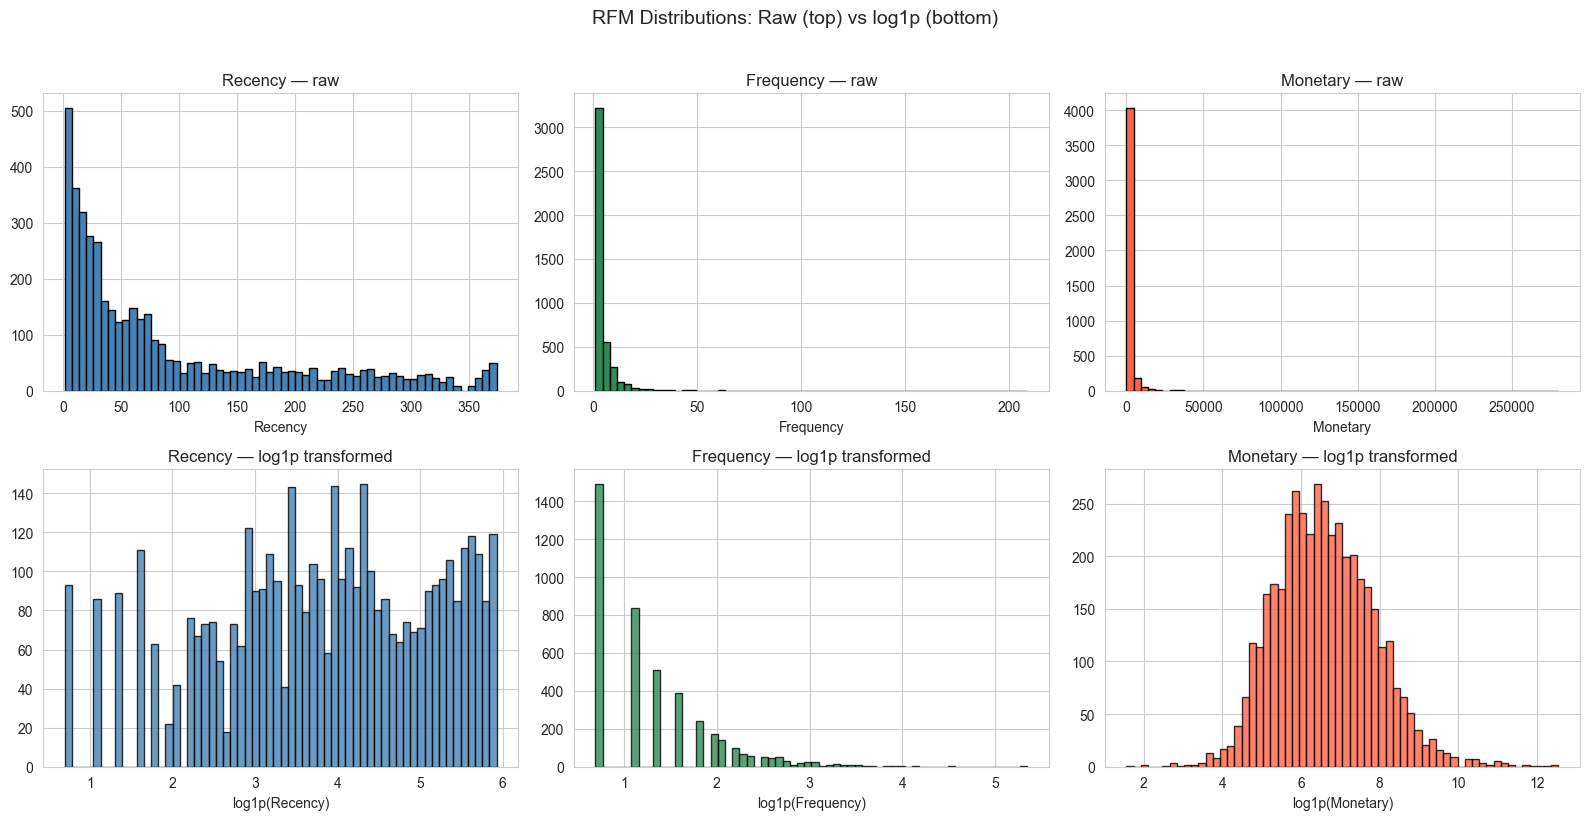

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
colors = ['steelblue', 'seagreen', 'tomato']
for i, (col, color) in enumerate(zip(['Recency', 'Frequency', 'Monetary'], colors)):
    axes[0, i].hist(rfm[col], bins=60, color=color, edgecolor='black')
    axes[0, i].set_title(f'{col} — raw')
    axes[0, i].set_xlabel(col)

    axes[1, i].hist(np.log1p(rfm[col]), bins=60, color=color, edgecolor='black', alpha=0.8)
    axes[1, i].set_title(f'{col} — log1p transformed')
    axes[1, i].set_xlabel(f'log1p({col})')

plt.suptitle('RFM Distributions: Raw (top) vs log1p (bottom)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

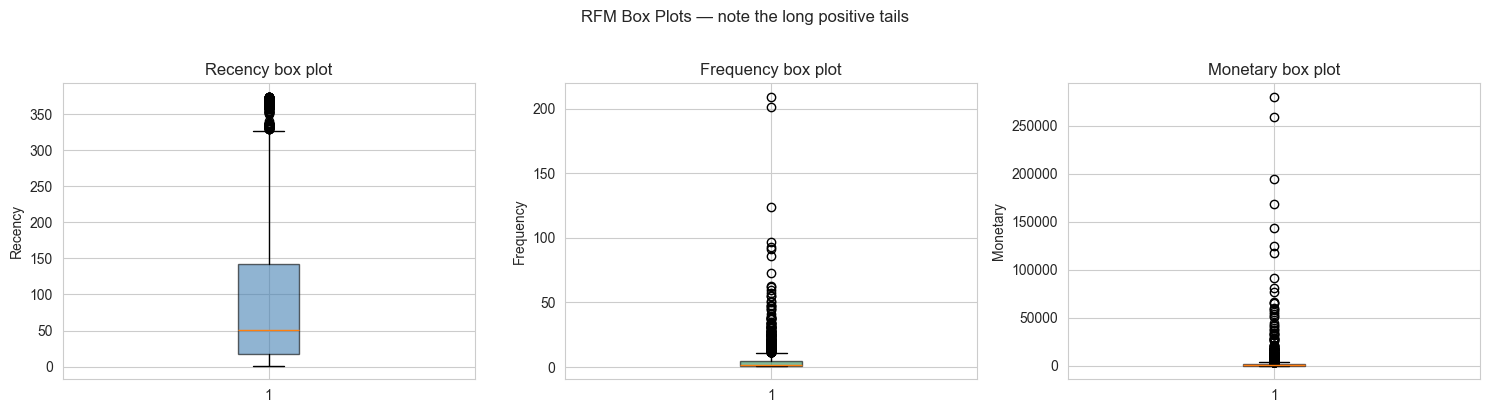

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ['Recency', 'Frequency', 'Monetary'], colors):
    ax.boxplot(rfm[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title(f'{col} box plot')
    ax.set_ylabel(col)
plt.suptitle('RFM Box Plots — note the long positive tails', y=1.02)
plt.tight_layout(); plt.show()

## 6. Verify No Nulls & Save

We confirm there are no missing values in the final RFM table before saving. The cleaned file `data/customer_rfm.csv` is the sole input to notebook 03.

In [10]:
print('Missing values in RFM table:')
print(rfm.isnull().sum())
print()
print('Final RFM shape:', rfm.shape)
print('Unique customers:', rfm['CustomerID'].nunique())

Missing values in RFM table:


CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

Final RFM shape: (4338, 4)
Unique customers: 4338


In [11]:
rfm.to_csv('data/customer_rfm.csv', index=False)
print('Saved -> data/customer_rfm.csv')
rfm.head()

Saved -> data/customer_rfm.csv


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
